<a href="https://colab.research.google.com/github/sarahabdinnn/Data-Analysis-Projects/blob/main/Los_Angeles_Crimes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("crimes.csv")
print (df.head())
print (df.info())

       DR_NO   Date Rptd    DATE OCC  TIME OCC    AREA NAME  \
0  220314085  2022-07-22  2020-05-12      1110    Southwest   
1  222013040  2022-08-06  2020-06-04      1620      Olympic   
2  220614831  2022-08-18  2020-08-17      1200    Hollywood   
3  231207725  2023-02-27  2020-01-27       635  77th Street   
4  220213256  2022-07-14  2020-07-14       900      Rampart   

         Crm Cd Desc  Vict Age Vict Sex Vict Descent Weapon Desc  Status Desc  \
0  THEFT OF IDENTITY        27        F            B         NaN  Invest Cont   
1  THEFT OF IDENTITY        60        M            H         NaN  Invest Cont   
2  THEFT OF IDENTITY        28        M            H         NaN  Invest Cont   
3  THEFT OF IDENTITY        37        M            H         NaN  Invest Cont   
4  THEFT OF IDENTITY        79        M            B         NaN  Invest Cont   

                                  LOCATION  
0  2500 S  SYCAMORE                     AV  
1  3300    SAN MARINO                   ST  

In [3]:
print(df.isnull().sum())

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64


In [4]:
df['Vict Sex']=df['Vict Sex'].fillna('Prefer not to say')
df['Vict Descent']=df['Vict Descent'].fillna('Prefer not to say')
df['Weapon Desc']=df['Weapon Desc'].fillna('No weapon/Unknown')

In [5]:
print(df.isnull().sum())

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Weapon Desc     0
Status Desc     0
LOCATION        0
dtype: int64


In [6]:
df.drop_duplicates()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,No weapon/Unknown,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,No weapon/Unknown,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,No weapon/Unknown,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,No weapon/Unknown,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,No weapon/Unknown,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,No weapon/Unknown,Invest Cont,5300 DENNY AV
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,No weapon/Unknown,Invest Cont,12500 BRANFORD ST
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV


In [7]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")

In [8]:
##fix datatypes
df['date_occ']=pd.to_datetime(df['date_occ'])
df['date_rptd']=pd.to_datetime(df['date_rptd'])
print (df.head())

       dr_no  date_rptd   date_occ  time_occ    area_name        crm_cd_desc  \
0  220314085 2022-07-22 2020-05-12      1110    Southwest  THEFT OF IDENTITY   
1  222013040 2022-08-06 2020-06-04      1620      Olympic  THEFT OF IDENTITY   
2  220614831 2022-08-18 2020-08-17      1200    Hollywood  THEFT OF IDENTITY   
3  231207725 2023-02-27 2020-01-27       635  77th Street  THEFT OF IDENTITY   
4  220213256 2022-07-14 2020-07-14       900      Rampart  THEFT OF IDENTITY   

   vict_age vict_sex vict_descent        weapon_desc  status_desc  \
0        27        F            B  No weapon/Unknown  Invest Cont   
1        60        M            H  No weapon/Unknown  Invest Cont   
2        28        M            H  No weapon/Unknown  Invest Cont   
3        37        M            H  No weapon/Unknown  Invest Cont   
4        79        M            B  No weapon/Unknown  Invest Cont   

                                  location  
0  2500 S  SYCAMORE                     AV  
1  3300    SAN

In [9]:
df['time_occ'] = df['time_occ'].astype(int).astype(str).str.zfill(4)
df['time_occ'] = df['time_occ'].str[:2] + ':' + df['time_occ'].str[2:]
print(df['time_occ'].head())

0    11:10
1    16:20
2    12:00
3    06:35
4    09:00
Name: time_occ, dtype: object


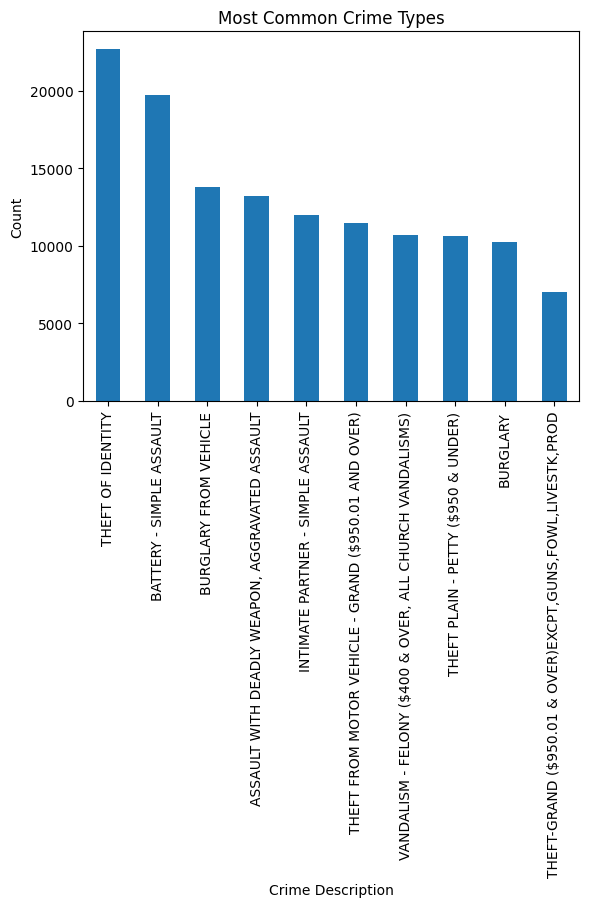

In [10]:
##most common crimes
df['crm_cd_desc'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Crime Types')
plt.xlabel('Crime Description')
plt.ylabel('Count')
plt.show()

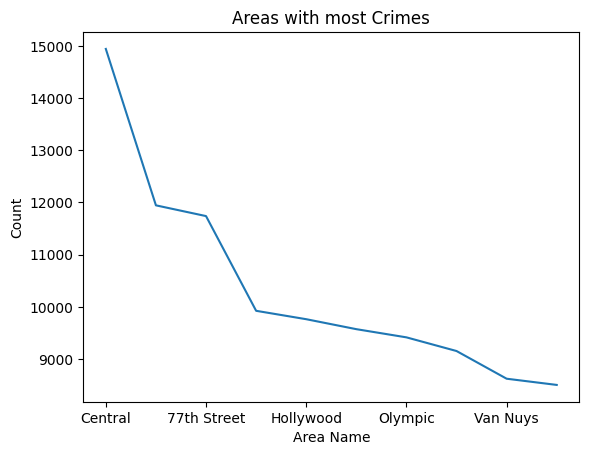

In [11]:
## which area has the most crimes?
df['area_name'].value_counts().head(10).plot(kind='line')
plt.title('Areas with most Crimes')
plt.xlabel('Area Name')
plt.ylabel('Count')
plt.show()

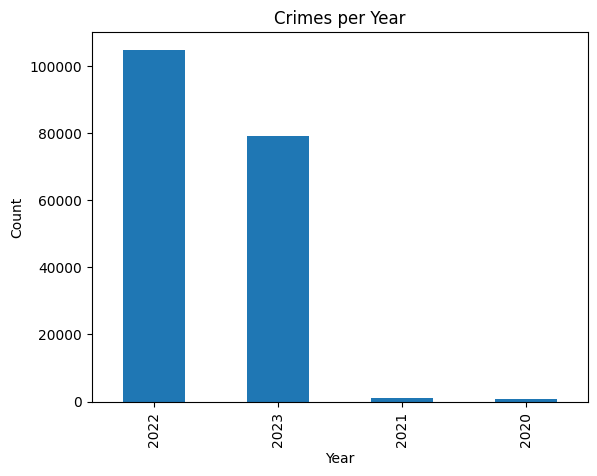

In [12]:
##crimes per year
df['date_occ'].dt.year.value_counts().plot(kind='bar')
plt.title('Crimes per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

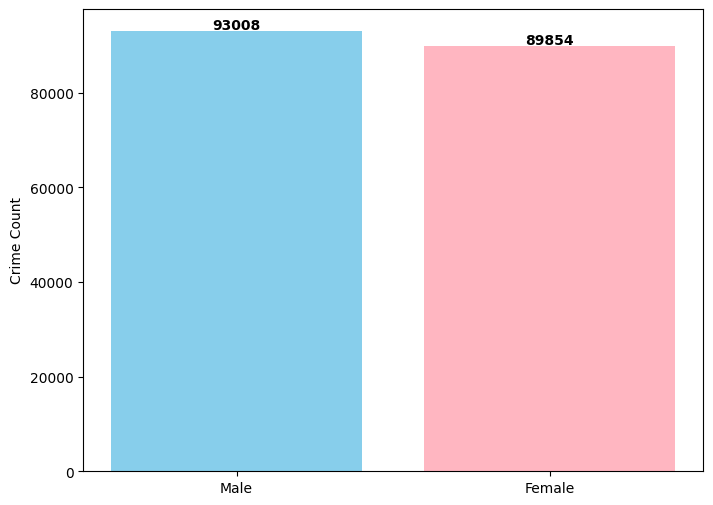

In [13]:
gender_counts=df['vict_sex'].value_counts()
comparison_data=gender_counts[["M","F"]]
comparison_data.index=['Male','Female']
plt.figure(figsize=(8, 6))
plt.ylabel('Crime Count')
plt.bar(comparison_data.index, comparison_data.values, color=['skyblue', 'lightpink'])
for i, v in enumerate(comparison_data.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

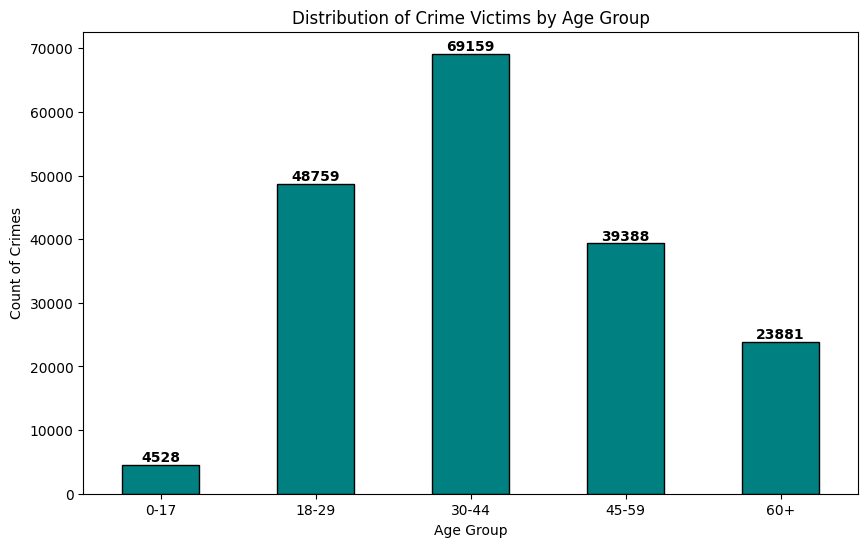

In [14]:
##crime distrubtion by age
valid_ages = df[df['vict_age'] > 0]['vict_age']
bins = [0, 18, 30, 45, 60, 100]
labels = ['0-17', '18-29', '30-44', '45-59', '60+']
age_groups = pd.cut(valid_ages, bins=bins, labels=labels, right=False)
age_counts = age_groups.value_counts().sort_index()
plt.figure(figsize=(10, 6))
age_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Distribution of Crime Victims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count of Crimes')
plt.xticks(rotation=0)
for i, v in enumerate(age_counts):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

In [15]:
print (df.head())

       dr_no  date_rptd   date_occ time_occ    area_name        crm_cd_desc  \
0  220314085 2022-07-22 2020-05-12    11:10    Southwest  THEFT OF IDENTITY   
1  222013040 2022-08-06 2020-06-04    16:20      Olympic  THEFT OF IDENTITY   
2  220614831 2022-08-18 2020-08-17    12:00    Hollywood  THEFT OF IDENTITY   
3  231207725 2023-02-27 2020-01-27    06:35  77th Street  THEFT OF IDENTITY   
4  220213256 2022-07-14 2020-07-14    09:00      Rampart  THEFT OF IDENTITY   

   vict_age vict_sex vict_descent        weapon_desc  status_desc  \
0        27        F            B  No weapon/Unknown  Invest Cont   
1        60        M            H  No weapon/Unknown  Invest Cont   
2        28        M            H  No weapon/Unknown  Invest Cont   
3        37        M            H  No weapon/Unknown  Invest Cont   
4        79        M            B  No weapon/Unknown  Invest Cont   

                                  location  
0  2500 S  SYCAMORE                     AV  
1  3300    SAN MARIN

Text(0, 0.5, 'Weapon Used')

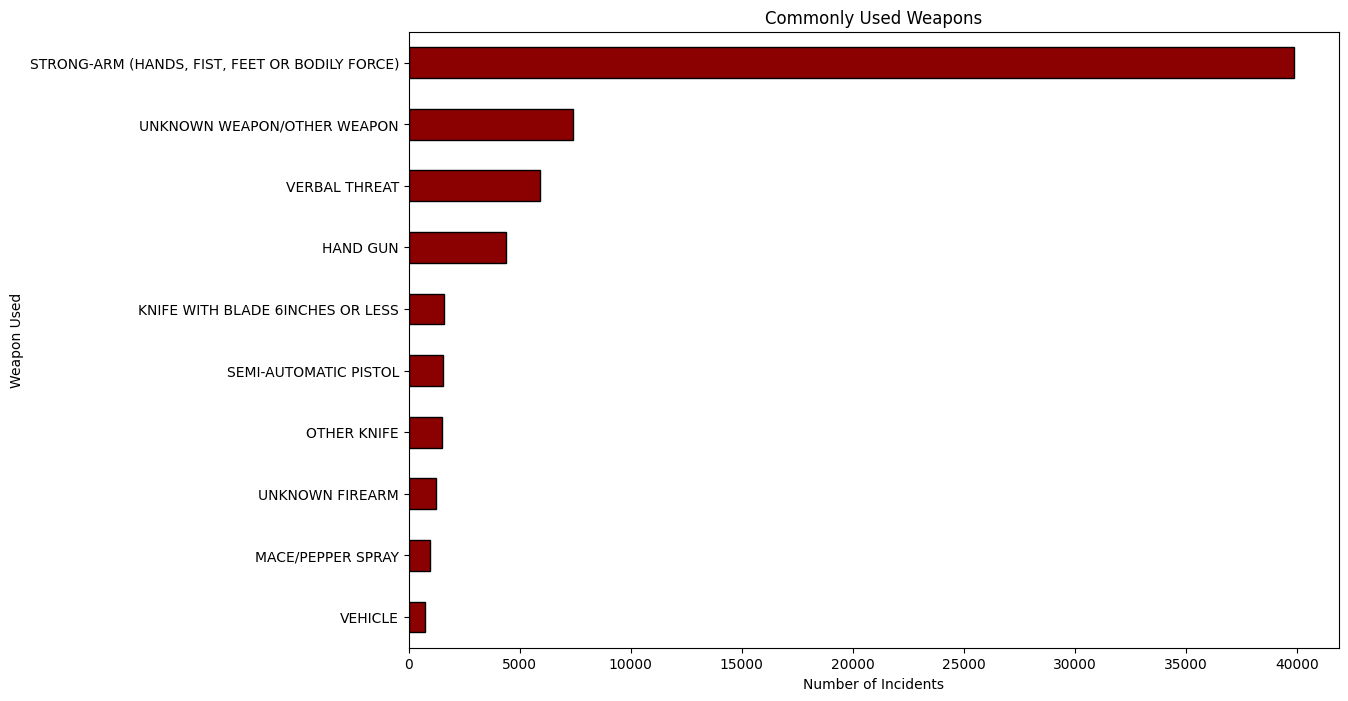

In [16]:
## most weapon used
clean_mask = ~df['weapon_desc'].str.contains('No weapon/Unknown', case=False, na=False)
df_known = df[clean_mask]
top_known = df_known['weapon_desc'].value_counts().head(10)
# 4. Create the chart
plt.figure(figsize=(12, 8))
top_known.sort_values().plot(kind='barh', color='darkred', edgecolor='black')

plt.title('Commonly Used Weapons')
plt.xlabel('Number of Incidents')
plt.ylabel('Weapon Used')

In [17]:
df.to_csv('cleaned_crimes_data.csv', index=False)